This notebook contains additional model evaluation.

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import zipfile
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator
from pathlib import Path
from scipy import stats

from ml_baselines.data import read_agage
from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.modelling.predict import load_baseline_model, BaselineLabelledObservations

from ml_baselines.config import Config
cfg = Config()

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

## Comparing Model Performance Across Gases

In [2]:
# Initialise and load model
site = "CGO"
model, extra_info = load_baseline_model(site=site, model_type=cfg.model_type, suffix="final", timestamp=None)

y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                 model=model, 
                                                 scaler=extra_info['scaler'],
                                                 prediction_mode="full", 
                                                 prediction_threshold=extra_info['model_inputs']['prediction_threshold'],
                                                 time_shift_hours=extra_info['model_inputs']['time_shift_hours'],
                                                 return_proba=True)

Loaded model from C:\Users\kirst\OneDrive\Kirstin\Uni\Year4\MSciProject\final_code\ml-baselines\models\CGO\mlp_model_2026-05-13_11-19_final.joblib
Predicting on full set for site: CGO with prediction threshold: 0.7
... loading full data for site: CGO, period: 1978-2024
Precision: 0.762
Recall: 0.674
F1 Score: 0.715


In [3]:
species_list = ["ch4", "cf4", "cfc-12", "ch2cl2", "ch3br", "hcfc-22", "hfc-125", "hfc-134a", "n2o", "sf6"]

species_dict = {}
site_species_list = []
for species in species_list:
    print(f"Evaluating {species}...")
    try:
        df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
        labelled_obs_here = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
    except (KeyError, ValueError) as e:
        print(f"Skipping. {species} not available at {site}.\n")
        continue
    site_species_list.append(species)
    labelled_obs_here.print_monthly_stats()
    species_dict[species] = {
        'monthly_scores': labelled_obs_here.monthly_scores,
        'missing_months': labelled_obs_here.missing_months,
        'anomaly_months': labelled_obs_here.anomaly_months,
        'total_months': len(labelled_obs_here.monthly_means),
    }
    print('')

Evaluating ch4...
Found 0 missing months, and 7 anomaly months (with 6, 1, and 0 months with deviations greater than 1, 3, and 5 standard deviations respectively).
train set - MAE: 0.358, MAPE: 0.020%, bias: -0.160, RMSE: 0.761
valida set - MAE: 0.718, MAPE: 0.039%, bias: -0.308, RMSE: 1.030
test set - MAE: 0.544, MAPE: 0.031%, bias: -0.161, RMSE: 0.860
full set - MAE: 0.544, MAPE: 0.031%, bias: -0.161, RMSE: 0.860

Evaluating cf4...
Found 0 missing months, and 2 anomaly months (with 1, 0, and 1 months with deviations greater than 1, 3, and 5 standard deviations respectively).
train set - MAE: 0.007, MAPE: 0.008%, bias: -0.002, RMSE: 0.009
valida set - MAE: 0.039, MAPE: 0.045%, bias: -0.016, RMSE: 0.045
test set - MAE: 0.013, MAPE: 0.016%, bias: -0.004, RMSE: 0.020
full set - MAE: 0.013, MAPE: 0.016%, bias: -0.004, RMSE: 0.020

Evaluating cfc-12...
Found 0 missing months, and 0 anomaly months (with 0, 0, and 0 months with deviations greater than 1, 3, and 5 standard deviations respecti

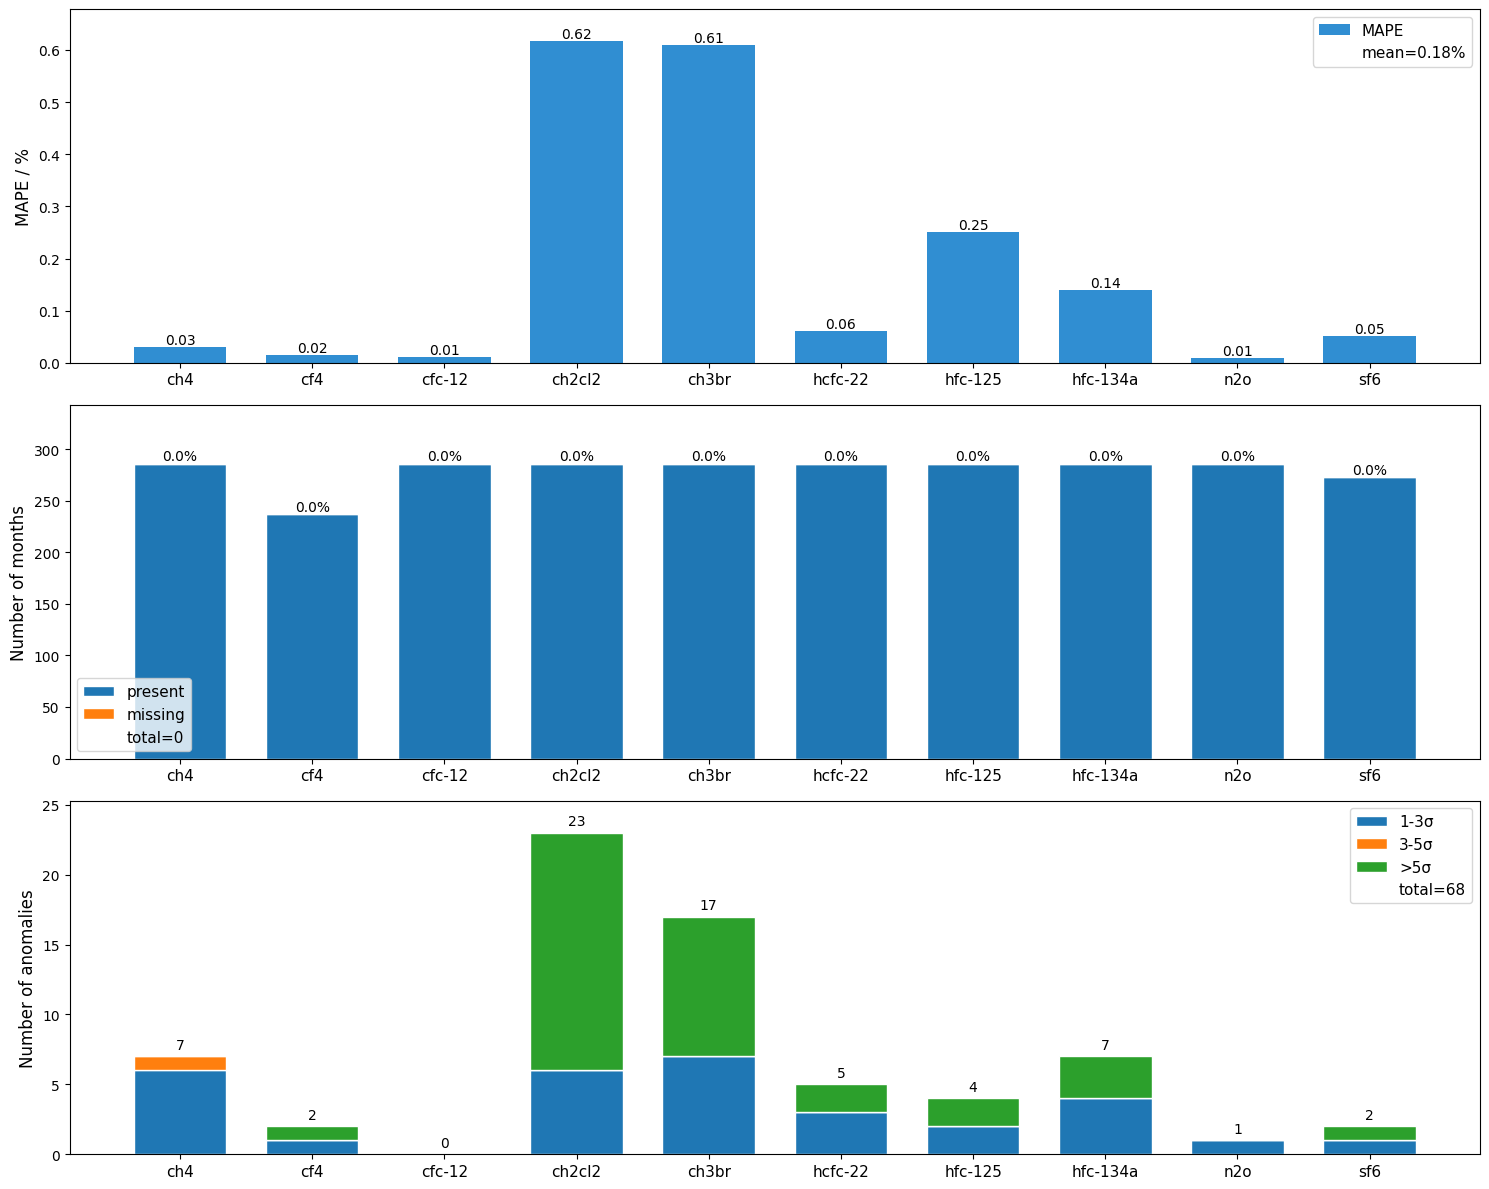

In [4]:
## compare results across species
eval_set = "test"

fig, axes = plt.subplots(3,1,figsize=(15, 12))
x = np.arange(len(site_species_list))
width = 0.7

# MAPE
scores = [species_dict[species]['monthly_scores'][eval_set]["MAPE"] for species in site_species_list]
bars = axes[0].bar(x, scores, width=width, label="MAPE", color='#308ed2')
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{score:.2f}", ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(scores)*1.1)
axes[0].set_ylabel("MAPE / %", fontsize=12)
axes[0].legend(handles=[bars, Patch(color='none', label=f'mean={np.mean(scores):.2f}%')], fontsize=11)

# missing months
missing_months = [len(species_dict[species]['missing_months']) for species in site_species_list]
present_months = [species_dict[species]['total_months'] - len(species_dict[species]['missing_months']) for species in site_species_list]
present_bars = axes[1].bar(x, present_months, width=width, label='present', edgecolor='#ffffff')
missing_bars = axes[1].bar(x, missing_months, width=width, bottom=present_months, label='missing', edgecolor='#ffffff')
for i, (xi, miss, total) in enumerate(zip(x, missing_months, [p+m for p,m in zip(present_months, missing_months)])):
    axes[1].text(xi, total + 0.3, f"{100*miss/total:.1f}%", ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, (max(present_months)+max(missing_months))*1.2)
axes[1].set_ylabel("Number of months", fontsize=12)
axes[1].legend(handles=[present_bars, missing_bars,Patch(color='none', label=f'total={sum(missing_months)}')], fontsize=11)

# anomalies
anomalies_1 = [len(species_dict[species]['anomaly_months'][1]) for species in site_species_list]
anomalies_3 = [len(species_dict[species]['anomaly_months'][3]) for species in site_species_list]
anomalies_5 = [len(species_dict[species]['anomaly_months'][5]) for species in site_species_list]
total_anomalies = [len(set(species_dict[s]['anomaly_months'].get(1, [])) | 
                       set(species_dict[s]['anomaly_months'].get(3, [])) | 
                       set(species_dict[s]['anomaly_months'].get(5, []))) for s in site_species_list]
excl_1 = excl_1 = [a-b for a,b in zip(anomalies_1, anomalies_3)]  # 1-3σ only
excl_3 = [a-b for a,b in zip(anomalies_3, anomalies_5)]  # 3-5σ only
excl_5 = anomalies_5
b1 = axes[2].bar(x, excl_1, width, label='1-3σ', edgecolor='#ffffff')
b2 = axes[2].bar(x, excl_3, width, bottom=excl_1, label='3-5σ', edgecolor='#ffffff')
b3 = axes[2].bar(x, excl_5, width, bottom=[a+b for a,b in zip(excl_1, excl_3)], label='>5σ', edgecolor='#ffffff')
for xi, total in zip(x, total_anomalies):
    axes[2].text(xi, total + 0.3, str(total), ha='center', va='bottom', fontsize=10)
axes[2].set_ylim(0, max(total_anomalies)*1.1)
axes[2].set_ylabel("Number of anomalies", fontsize=12)
axes[2].legend(handles=[b1, b2, b3, Patch(color='none', label=f'total={sum(total_anomalies)}')], fontsize=11)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(site_species_list, fontsize=11)

fig.tight_layout()
plt.show()

## Comparing Model Performance Across Sites

In [5]:
sites = list(cfg.site_dict.keys())
species_list = ["ch4", "cf4", "cfc-12", "ch2cl2", "ch3br", "hcfc-22", "hfc-125", "hfc-134a", "n2o", "sf6"]

In [6]:
# extract MAPE
mape_dict = {}
for site in sites:
    mape_dict[site] = {}
    model, extra_info = model, extra_info = load_baseline_model(site, cfg.model_type, 
                                                                timestamp=None, suffix="final",
                                                                verbose=False)
    scaler = extra_info['scaler']
    threshold = extra_info['model_inputs']['prediction_threshold']
    time_shift_hours = extra_info['model_inputs']['time_shift_hours']

    y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                    model=model, 
                                                    scaler=scaler,
                                                    prediction_mode="test", 
                                                    prediction_threshold=threshold,
                                                    time_shift_hours=time_shift_hours,
                                                    return_proba=True,
                                                    verbose=False)

    with zipfile.ZipFile(Path(cfg.obs_path), 'r') as zf:
            all_files = zf.namelist()
            available = [(f.split('/')[1], f.split('_')[1].upper()) 
                        for f in all_files if f.endswith('.nc')]
            available_species = sorted(set([a[0] for a in available if a[1] == site.upper()]))
            assert len(available_species) > 1

    for species in available_species:
        if species in species_list:
            df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
            try:
                labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
            except:
                continue
            mape_dict[site][species] = {}
            labelled_obs_species.print_monthly_stats(verbose=False)
            mape = labelled_obs_species.monthly_scores["test"]["MAPE"]
            mape_dict[site][species]['mape']=mape.item()

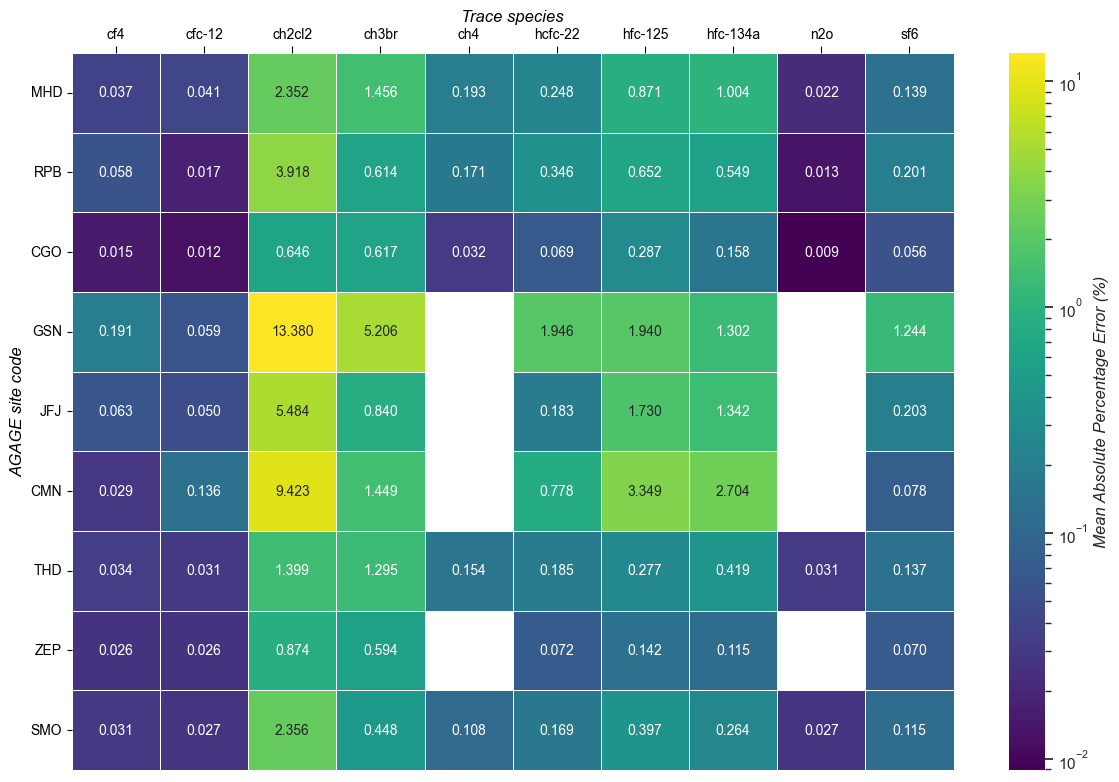

In [7]:
mape_df = pd.DataFrame({
    site: {species: values['mape'] for species, values in species_dict.items()}
    for site, species_dict in mape_dict.items()
}).T

# plot MAPE heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.set_theme(style='ticks', font='Arial')

sns.heatmap(
        mape_df,
        annot=True, 
        fmt=".3f",
        annot_kws={"fontsize": 10},
        cmap='viridis', 
        linewidths=0.5, 
        linecolor='white', 
        norm = mcolors.LogNorm(vmin=mape_df.min().min(), vmax=mape_df.max().max())
        )

plt.yticks(rotation=0)
plt.ylabel('AGAGE site code', fontstyle='italic', fontsize=12)

plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, 
                labeltop=True, size=10)
plt.tick_params(axis='x', which='both', top=True, size=5)

ax.xaxis.set_label_position('top')
plt.xlabel('Trace species', fontstyle='italic', fontsize=12)

cbar = ax.collections[0].colorbar
cbar.set_label('Mean Absolute Percentage Error (%)', fontstyle='italic', fontsize=12)

plt.tight_layout()

## Coefficient of Variation

Loaded model from C:\Users\kirst\OneDrive\Kirstin\Uni\Year4\MSciProject\final_code\ml-baselines\models\MHD\mlp_model_2026-05-13_11-23_final.joblib
CV on train set for hfc-134a at MHD: 0.003


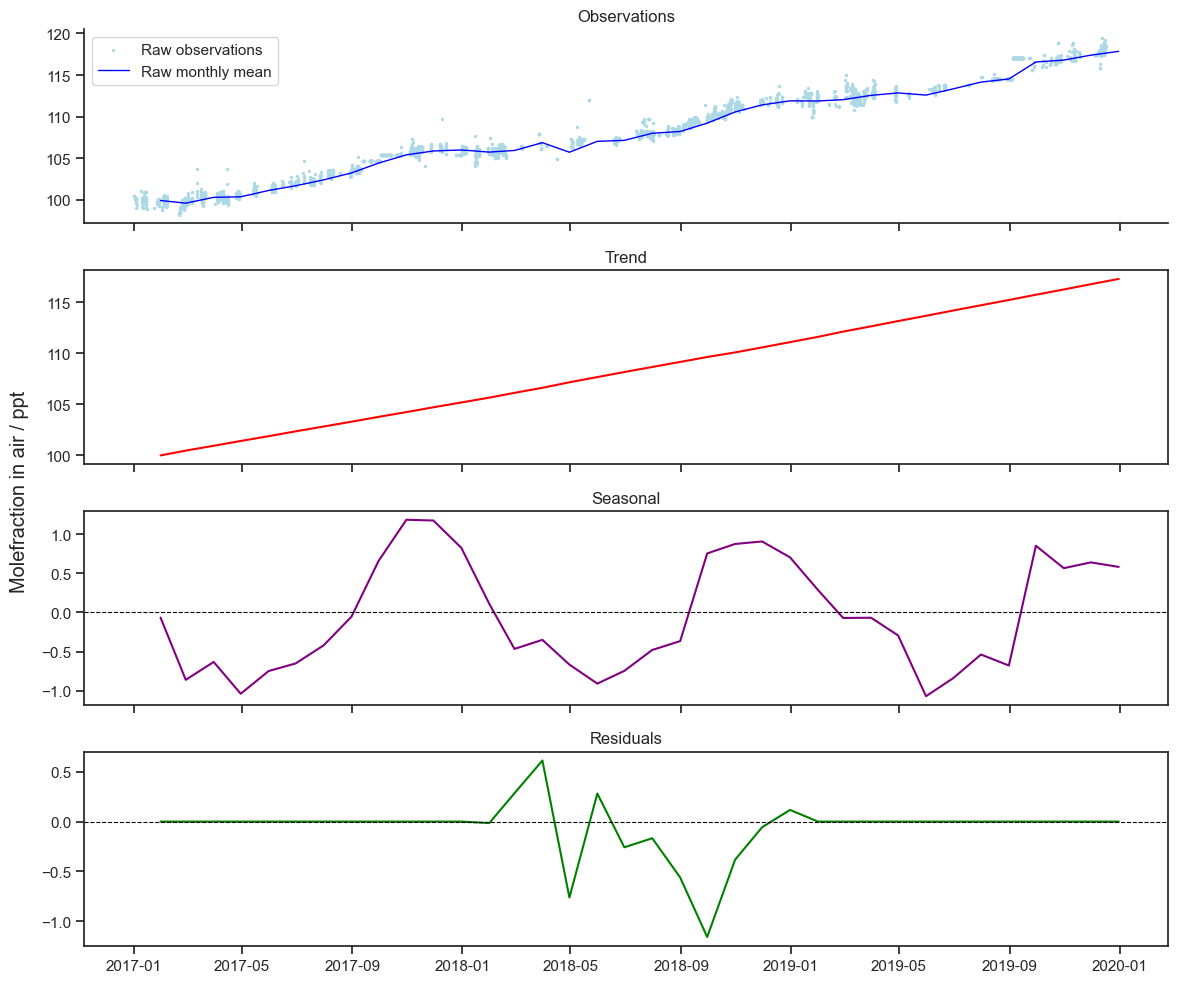

In [8]:
# explore one species
site = 'MHD'
species = 'hfc-134a'
model_type = cfg.model_type

model, extra_info = model, extra_info = load_baseline_model(site, model_type, timestamp=None, suffix="final")
scaler = extra_info['scaler']
threshold = extra_info['model_inputs']['prediction_threshold']
y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                model=model, 
                                                scaler=scaler,
                                                prediction_mode="full", 
                                                prediction_threshold=threshold,
                                                return_proba=True,
                                                verbose=False)

df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
labelled_obs_species.calculate_true_baseline_cv(eval_mode="train", remove_seasonality=True, plot_stl=True, verbose=False) # plot seasonality decomposition as sanity check
print(f"CV on {labelled_obs_species.baseline_cv['eval_mode']} set for {species} at {site}: {labelled_obs_species.baseline_cv['cv']:.3f}")

In [9]:
# loop through sites and species
sites = list(cfg.site_dict.keys())

cv_dict = {}
remove_seasonality = True
for site in sites:
    model, extra_info = model, extra_info = load_baseline_model(site, model_type, timestamp=None, suffix="final", verbose=False)
    cv_dict[site] = {}
    scaler = extra_info['scaler']
    threshold = extra_info['model_inputs']['prediction_threshold']
    time_shift_hours = extra_info['model_inputs']['time_shift_hours']

    y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                    model=model, 
                                                    scaler=scaler,
                                                    prediction_mode="full", 
                                                    prediction_threshold=threshold,
                                                    time_shift_hours=time_shift_hours,
                                                    return_proba=True,
                                                    verbose=False)

    with zipfile.ZipFile(Path(cfg.obs_path), 'r') as zf:
            all_files = zf.namelist()
            available = [(f.split('/')[1], f.split('_')[1].upper()) 
                        for f in all_files if f.endswith('.nc')]
            available_species = sorted(set([a[0] for a in available if a[1] == site.upper()]))

    num_low_coverage = 0
    for species in available_species:
        df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
        try:
            labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
            labelled_obs_species.calculate_true_baseline_cv(eval_mode="train", remove_seasonality=remove_seasonality, verbose=False)
        except Exception as e:
            continue
        cv_dict[site][species] = {}
        baseline_cv = labelled_obs_species.baseline_cv['cv']
        cv_dict[site][species]['cv'] = baseline_cv
        if labelled_obs_species.baseline_cv['pct_monthly_coverage'] < 75:
            num_low_coverage += 1

        labelled_obs_species.print_monthly_stats(verbose=False)
        mape = labelled_obs_species.monthly_scores["test"]["MAPE"]
        cv_dict[site][species]['mape'] = mape.item()

    if num_low_coverage > 0 and remove_seasonality==True: 
        print(f"   {num_low_coverage}/{len(available_species)} of species had low coverage.")

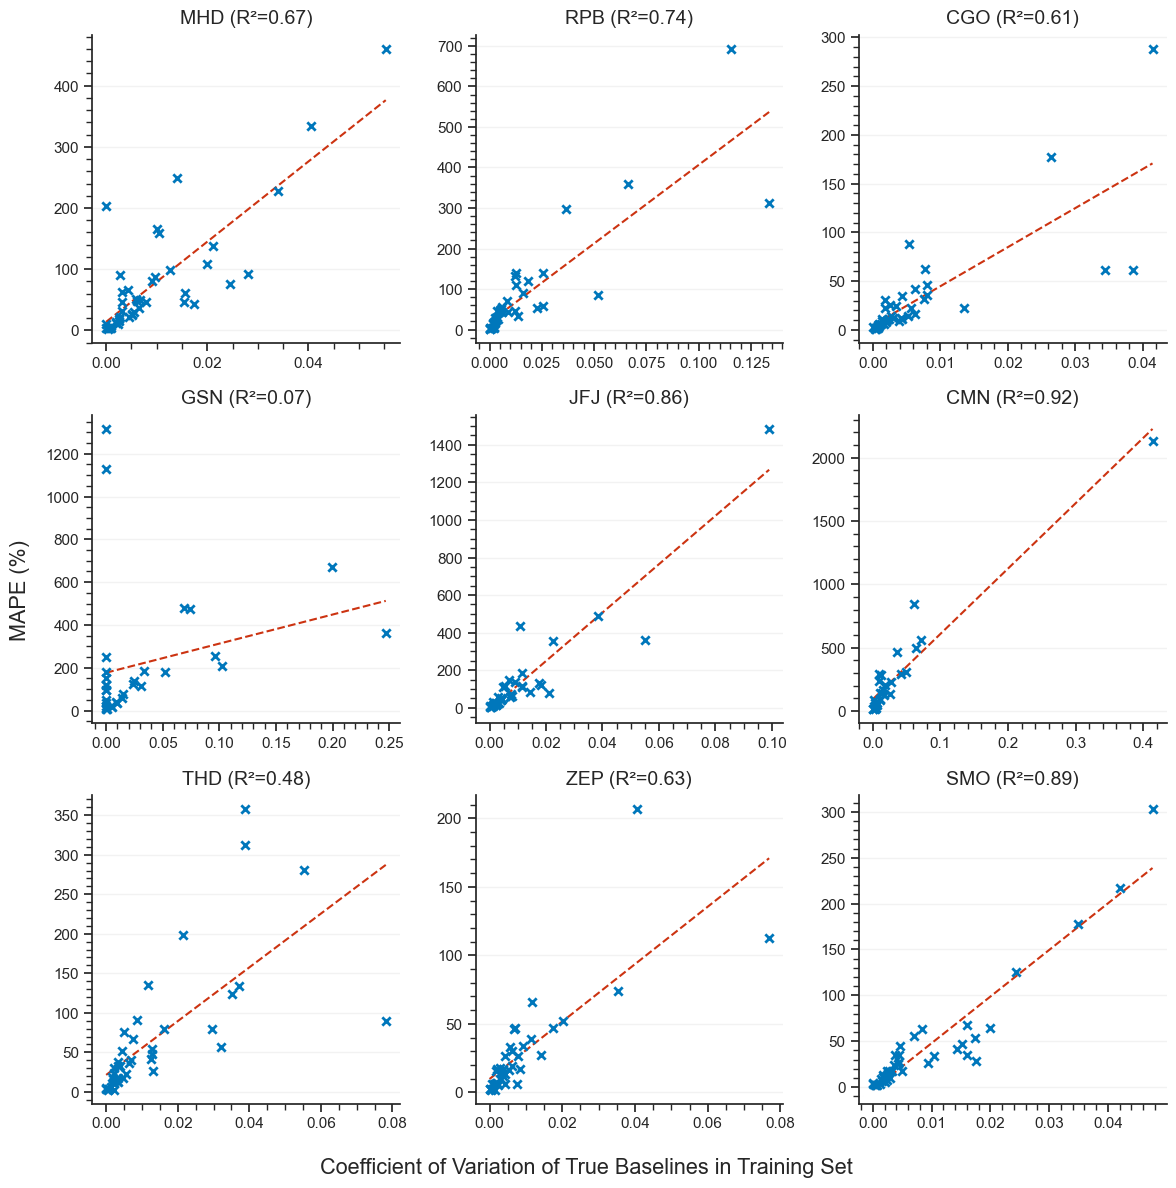

In [10]:
# plot
fig, axes = plt.subplots(3, 3, figsize=(12,12))
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
axes_flat = axes.flatten()
for i, site in enumerate([s for s in cv_dict.keys() if s != 'eval_mode']):
    ax = axes_flat[i]
    species_list = [species for species in cv_dict[site]]
    cvs = [cv_dict[site][species]['cv'] for species in species_list]
    mapes = [100 * cv_dict[site][species]['mape'] for species in species_list]
    nan_count=0
   
    ax.scatter(cvs, mapes, marker='x', color='#0077BB', zorder=3, linewidth=2)

    slope, intercept, r, _, _ = stats.linregress(cvs, mapes)
    x_line = np.linspace(min(cvs), max(cvs), 100)
    ax.plot(x_line, intercept + slope * x_line, color='#CC3311', linestyle='--', label=f'R²={r**2:.2f}')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(f"{site} (R²={r**2:.2f})", fontsize=14, pad=8)

for a in axes_flat:
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.grid(True, which='major', alpha=0.25)
    a.set_axisbelow(True)

fig.supxlabel("Coefficient of Variation of True Baselines in Training Set")
fig.supylabel("MAPE (%)")
fig.tight_layout()